In [1]:
%load_ext autoreload
%autoreload 2
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))  # make toolkit importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
mne.set_log_level('WARNING')

from toolkit import (
    RawAmplitudeFeature, TimeFrequencyFeature, RiemannianCovarianceFeature,
    RidgeLogisticDecoder, SVMDecoder,
    CVSplitter, cross_validate,
)
import torch

In [2]:
EPOCHS_PATH = '/jukebox/PNI-classes/students/NEU502/2026-NEU502B/binding/new_ICA/bids/derivatives/analysis4__4/sub-001/ses-01/meg/sub-001_ses-01_task-binding_epo.fif'
BEHAV_PATH  = '/usr/people/yl0124/projects/NEU502B/neu502b-2025/binding/data/2026-04-10/sub-001_events.csv'                    
RESULTS_PATH  = '/usr/people/yl0124/projects/NEU502B/neu502b-2025/binding/examples/results_alt'                     
epochs = mne.read_epochs(EPOCHS_PATH, preload=True)
df = pd.read_csv(BEHAV_PATH).sort_values('trial').reset_index(drop=True)

sfreq = epochs.info['sfreq']
times = epochs.times
n_trials = len(df)
print(f'Epochs shape: {epochs.get_data(picks="meg").shape}')
print(f'Trials: {n_trials}, sfreq: {sfreq} Hz, times: {times[0]:.3f}–{times[-1]:.3f} s')

Epochs shape: (1080, 192, 201)
Trials: 120, sfreq: 400.0 Hz, times: -0.100–0.400 s


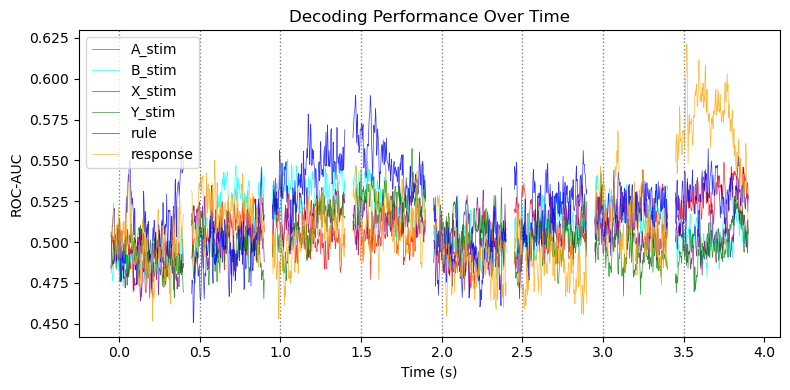

In [22]:
# test = np.load(os.path.join(RESULTS_PATH, 'decode_rule_raw_n3.npy'))
fig, ax = plt.subplots(figsize = (8, 4))
times = np.linspace(-0.05, 0.4, 181)

colors = {'A_stim': 'red', 'B_stim': 'cyan', 'rule': 'blue', 
            'X_stim': 'purple', 'Y_stim': 'green', 'response': 'orange', 'YY_match': 'orange', 'order_random': 'orange', 'ordered_random': 'orange', '' : 'black'}

for items in ['A_stim', 'B_stim', 'X_stim', 'Y_stim', "rule", "response"]:
    result = np.load(os.path.join(RESULTS_PATH, f'decode_{items}_raw_n3.npy'))
    for s in range(8): 
        ax.plot(times + s * 0.5, result[:, s, :].mean(axis = 0), color = colors[items], label = items if s == 0 else "", alpha = 0.8, linewidth = 0.5)

PHASE_OFFSETS = {
    "rule1": 0.0,
    "rule2": 1, 
    "rule3": 2,
    "transition": 3,
    "test1": 4,
    "test2": 5,
    'test3': 6,
    "response": 7,
}
for epoch in ["rule1", "rule2", "rule3", "transition", "test1", "test2", 'test3', "response"]:
    offset = PHASE_OFFSETS[epoch] * 0.5
    ax.axvline(offset, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Decoding Performance Over Time')
ax.legend()
plt.tight_layout()


In [ ]:
results = np.load(os.path.join(RESULTS_PATH, 'decode_rule_raw_n3.npy'))

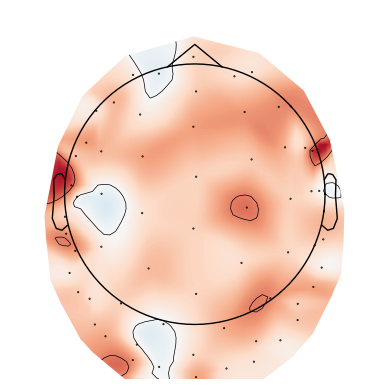

<Figure size 640x480 with 0 Axes>

In [25]:
meg_picks = mne.pick_types(epochs.info, meg=True, exclude=[])
meg_info = mne.pick_info(epochs.info, meg_picks)

scores = results[:, 3, :].mean(axis=1)

# Group channels that have the same sensor location (e.g. X/Y/Z components)
pos3d = np.array([ch['loc'][:3] for ch in meg_info['chs']])
pos_key = np.round(pos3d, 6)
_, groups = np.unique(pos_key, axis=0, return_inverse=True)

# topo_scores = np.array([scores[groups == g].mean() for g in range(groups.max() + 1)])
topo_scores = scores
topo_pos = np.array([pos3d[groups == g, :2].mean(axis=0) for g in range(groups.max() + 1)])

# Center and scale 2D positions for plotting
# topo_pos = topo_pos - topo_pos.mean(axis=0, keepdims=True)
# topo_pos = topo_pos / np.abs(topo_pos).max()

fig, ax = plt.subplots()
mne.viz.plot_topomap(
    topo_scores,
    topo_pos,
    axes=ax,
    cmap='RdBu_r',
    contours=1,
    sensors=True,
    vlim = (0.3, 0.7), 
    extrapolate='local', 
)


ax.set_title('Rule3 mean ROC-AUC topomap')
plt.tight_layout()
plt.show()

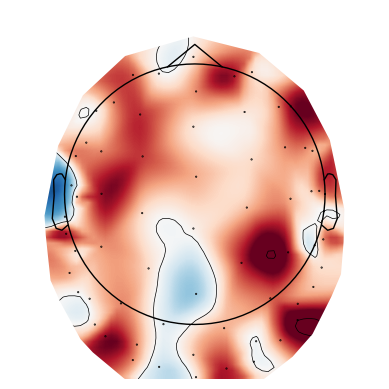

<Figure size 640x480 with 0 Axes>

In [31]:
results = np.load(os.path.join(RESULTS_PATH, 'decode_response_raw_n3.npy'))
meg_picks = mne.pick_types(epochs.info, meg=True, exclude=[])
meg_info = mne.pick_info(epochs.info, meg_picks)

scores = results[:, -1, :40].mean(axis=1)

# Group channels that have the same sensor location (e.g. X/Y/Z components)
pos3d = np.array([ch['loc'][:3] for ch in meg_info['chs']])
pos_key = np.round(pos3d, 6)
_, groups = np.unique(pos_key, axis=0, return_inverse=True)

# topo_scores = np.array([scores[groups == g].mean() for g in range(groups.max() + 1)])
topo_scores = scores
topo_pos = np.array([pos3d[groups == g, :2].mean(axis=0) for g in range(groups.max() + 1)])

# Center and scale 2D positions for plotting
# topo_pos = topo_pos - topo_pos.mean(axis=0, keepdims=True)
# topo_pos = topo_pos / np.abs(topo_pos).max()

fig, ax = plt.subplots()
mne.viz.plot_topomap(
    topo_scores,
    topo_pos,
    axes=ax,
    cmap='RdBu_r',
    contours=1,
    sensors=True,
    vlim = (0.3, 0.7), 
    extrapolate='local', 
)


ax.set_title('Rule3 mean ROC-AUC topomap')
plt.tight_layout()
plt.show()